In [ ]:
import pandas as pd
from sklearn import utils, preprocessing
import numpy as np 
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
import matplotlib.pyplot as plt
import joblib
import json
from datetime import datetime

df = pd.read_csv('Clean_Dataset.csv')
df = df.drop(columns=['Unnamed: 0','flight']) 
df = utils.shuffle(df,random_state=42)

# Step 1: Map ordinal columns
mapping_stops = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['stops'] = df['stops'].map(mapping_stops)

mapping_class = {'Economy': 0, 'Business': 1}
df['class'] = df['class'].map(mapping_class)


X=df.drop('price',axis="columns") #features 
Y=df['price'] #target

xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=42)

# Step 2: OneHot encode nominal columns
categorical_cols = ['airline', 'source_city', 'destination_city', 'arrival_time', 'departure_time']
numerical_cols=['duration','days_left']
ordinal_cols=['class','stops']

encoder_cat = preprocessing.OneHotEncoder(sparse_output=False)

xtrain_cat=encoder_cat.fit_transform(xtrain[categorical_cols])
xtest_cat=encoder_cat.transform(xtest[categorical_cols])


scaler=preprocessing.StandardScaler()

xtrain_num=scaler.fit_transform(xtrain[numerical_cols])
xtest_num=scaler.transform(xtest[numerical_cols])

ohe_cols = encoder_cat.get_feature_names_out(categorical_cols)

xtrain_final = pd.DataFrame(
    np.concatenate([xtrain[ordinal_cols].values, xtrain_num, xtrain_cat], axis=1),
    columns=ordinal_cols + numerical_cols + list(ohe_cols)
)
xtest_final = pd.DataFrame(
    np.concatenate([xtest[ordinal_cols].values, xtest_num, xtest_cat], axis=1),
    columns=ordinal_cols + numerical_cols + list(ohe_cols)
)
display(df)

In [ ]:
### Phase de comparaisson

models = {
    "Baseline (Dummy)": DummyRegressor(strategy="median"),
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=50,n_jobs=-1)
}
cross_validation_res=[]

for name,model in models.items():
    scores=cross_validate(
        model,
        xtrain_final,
        ytrain,
        cv=5,
        scoring=('neg_mean_absolute_error','r2'),
        n_jobs=-1
    )
    cross_validation_res.append({
        "Modèle": name,
        "MAE (CV Moyenne)": abs(scores['test_neg_mean_absolute_error'].mean()),
        "R² (CV Moyenne)": scores['test_r2'].mean()
    })

df_comparaison = pd.DataFrame(cross_validation_res).sort_values(by="MAE (CV Moyenne)")
display(df_comparaison)

R2: 0.9853090440978536
MAE: 1064.6540142295528
MSE. 7623184.184442257
RMSE. 2761.011442287456


Text(0.5, 1.0, 'Pred Vs Original price')

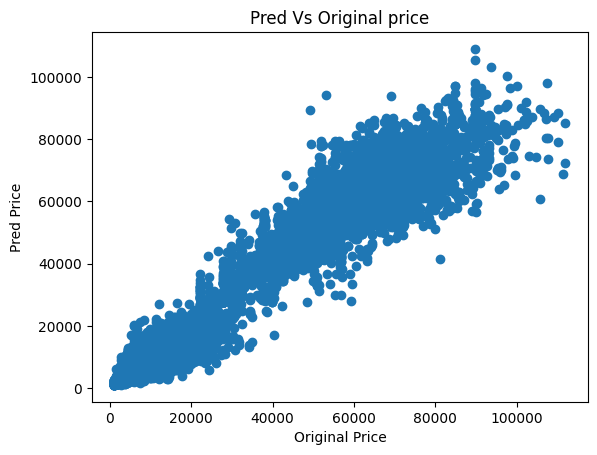

In [8]:
#Model 

rf_model = RandomForestRegressor(random_state=42,n_estimators=50,n_jobs=-1)
rf_model.fit(xtrain_final, ytrain)
predictions = rf_model.predict(xtest_final)

print("R2:", r2_score(ytest, predictions))
print("MAE:", mean_absolute_error(ytest, predictions))

print('MSE.', mean_squared_error(ytest,predictions))
print('RMSE.', root_mean_squared_error(ytest,predictions))

plt.scatter(ytest, predictions)
plt.xlabel('Original Price')
plt.ylabel('Pred Price')
plt.title('Pred Vs Original price')